In [1]:
# Importing the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [2]:
# Now let's load the data 
data = pd.read_csv('Fake Currency Detection.txt', header = None)

In [3]:
# Now let's rename the column names
data.columns = ['var', 'skew', 'curt', 'entr', 'auth']

In [4]:
# Now let's analyse the Top 5 rows of the data
data.head()

,var,skew,curt,entr,auth
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


### Data Exploration

In [5]:
# Noe let's check for more information about the Dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   var     1372 non-null   float64
 1   skew    1372 non-null   float64
 2   curt    1372 non-null   float64
 3   entr    1372 non-null   float64
 4   auth    1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [6]:
# Now let;s check for any null values in the data
data.isnull().sum()

var     0
skew    0
curt    0
entr    0
auth    0
dtype: int64

In [7]:
# Now let's check for any duplicate values in the dataset
data.duplicated().sum()

np.int64(24)

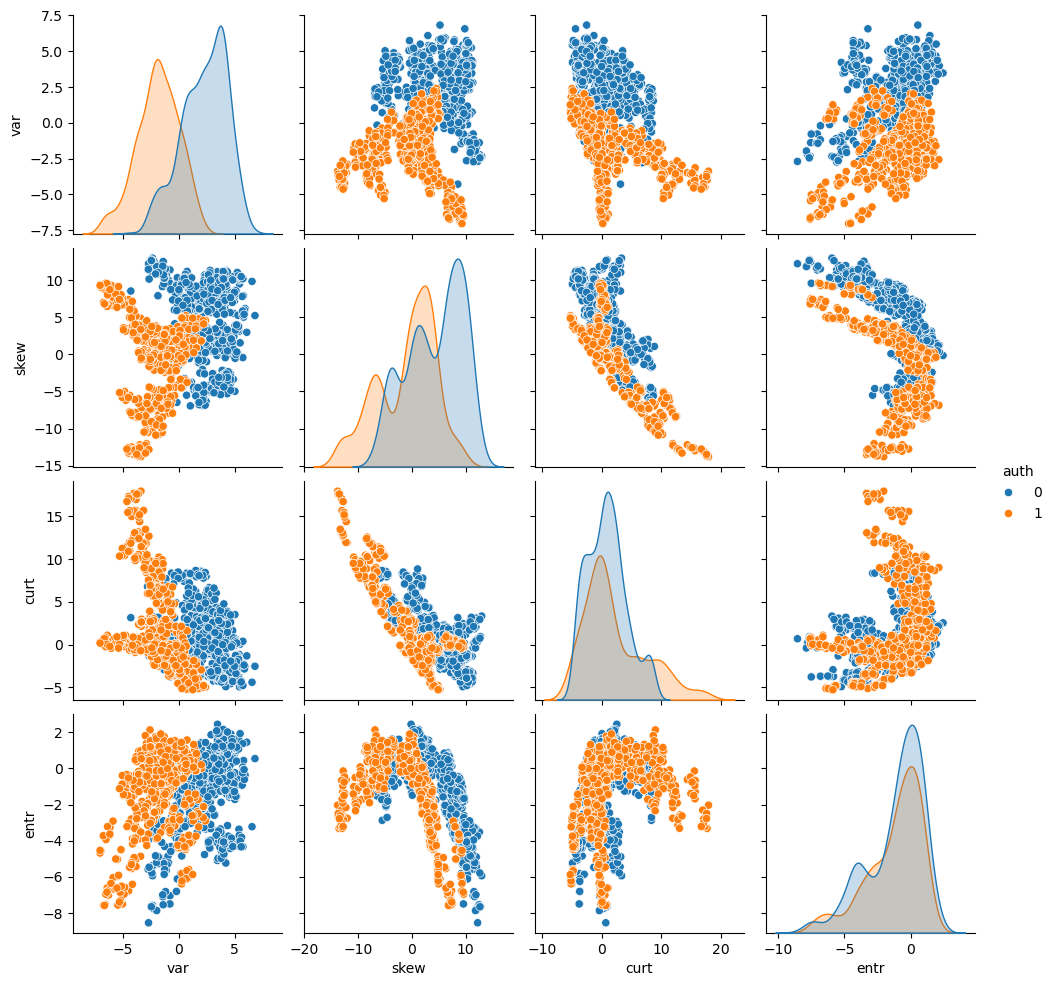

In [8]:
# Now let's draw a pair diagram to get an overview of the relationship
sns.pairplot(data, hue = 'auth')
plt.show()

##### From this pair plot we can make several interesting observations:

- The distribution of both variance and skewness appears to be quite different for the two target characteristics, while kurtosis and entropy appear to be more similar.
- There are clear linear and nonlinear trends in the input features.
- Some characteristics seem to be correlated.
- Some features seem to separate genuine and fake banknotes quite well.

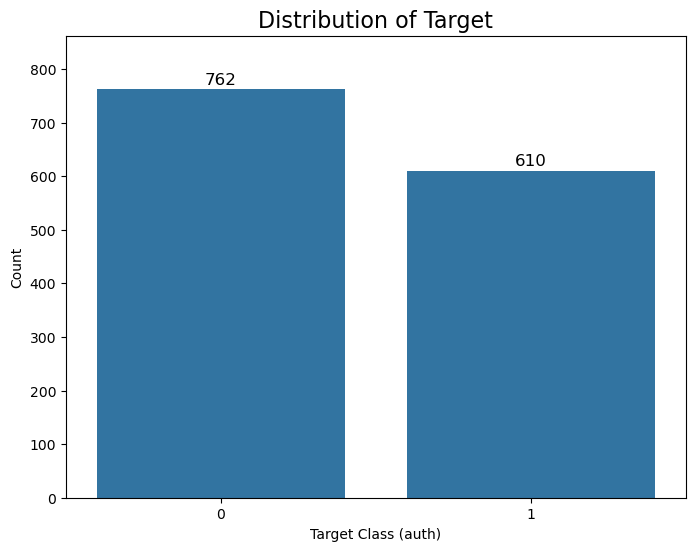

In [9]:
# Now let's check if our data is balanced against the target values
plt.figure(figsize=(8, 6))
ax = sns.countplot(x=data['auth'])
plt.title('Distribution of Target', fontsize=16)

# Get class counts
target_count = data['auth'].value_counts().sort_index()

# Annotate bar chart
for i, count in enumerate(target_count):
    plt.annotate(
        text=str(count),           # ✅ Required positional argument
        xy=(i, count + 10),        # ✅ x and y position
        ha='center',               # ✅ center align horizontally
        fontsize=12
    )

plt.ylim(0, max(target_count) + 100)
plt.xlabel("Target Class (auth)")
plt.ylabel("Count")
plt.show()

##### The dataset is fairly balanced, but for the binary classification task, we need to balance it perfectly.

### Data Processing


In [10]:
nb_to_delete = target_count[0] - target_count[1]
data = data.sample(frac = 1, random_state= 42).sort_values(by = 'auth')
data = data[nb_to_delete:]

In [11]:
data['auth'].value_counts()

auth
0    610
1    610
Name: count, dtype: int64

In [12]:
# Now we have a perfectly balanced dataset. Next, we need to divide the data into training and test sets
x = data.loc[:, data.columns != 'auth']
y = data.loc[:, data.columns == 'auth']

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.3, random_state= 42)

In [14]:
# Now let's standardize the data by using the StandardScalar method
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

### Logistic Regression for Fake Currency Detection

In [27]:
# Now let's train and test our model for fake currency detection
clf = LogisticRegression(solver= 'lbfgs', random_state= 42, multi_class= 'auto')
clf.fit(x_train, y_train.values.ravel())

C:\Users\irt\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='auto', random_state=42)

In [28]:
y_pred = np.array(clf.predict(x_test))
conf_mat = pd.DataFrame(confusion_matrix(y_test, y_pred),
                        columns=["Pred.Negative", "Pred.Positive"],
                        index=['Act.Negative', "Act.Positive"])
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = round((tn+tp)/(tn+fp+fn+tp), 4)
print(conf_mat)
print(f'\n Accuracy = {round(100*accuracy, 2)}%')

              Pred.Negative  Pred.Positive
Act.Negative            189              4
Act.Positive              0            173

 Accuracy = 98.91%


In [29]:
new_banknote = np.array([4.5, -8.1, 2.4, 1.4], ndmin=2)
new_banknote = scalar.transform(new_banknote)
print(f'Prediction:  Class{clf.predict(new_banknote)[0]}')
print(f'Probability [0/1]:  {clf.predict_proba(new_banknote)[0]}')

Prediction:  Class0
Probability [0/1]:  [0.6514116 0.3485884]


C:\Users\irt\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Our model predicts that this banknote is real.